In [ ]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
import platform

print(platform.platform())

Linux-6.6.122+-x86_64-with-glibc2.35


In [ ]:
!nvidia-smi

Fri May 29 06:04:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 48.5 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
model = YOLO("yolov8n.pt")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving traffic.jpg to traffic.jpg


In [ ]:
results = model("traffic.jpg")


image 1/1 /content/traffic.jpg: 384x640 13 persons, 1 bicycle, 17 cars, 2 motorcycles, 2 buss, 6 trucks, 49.8ms
Speed: 4.0ms preprocess, 49.8ms inference, 37.6ms postprocess per image at shape (1, 3, 384, 640)


In [ ]:
results[0].save(filename="output.jpg")

'output.jpg'

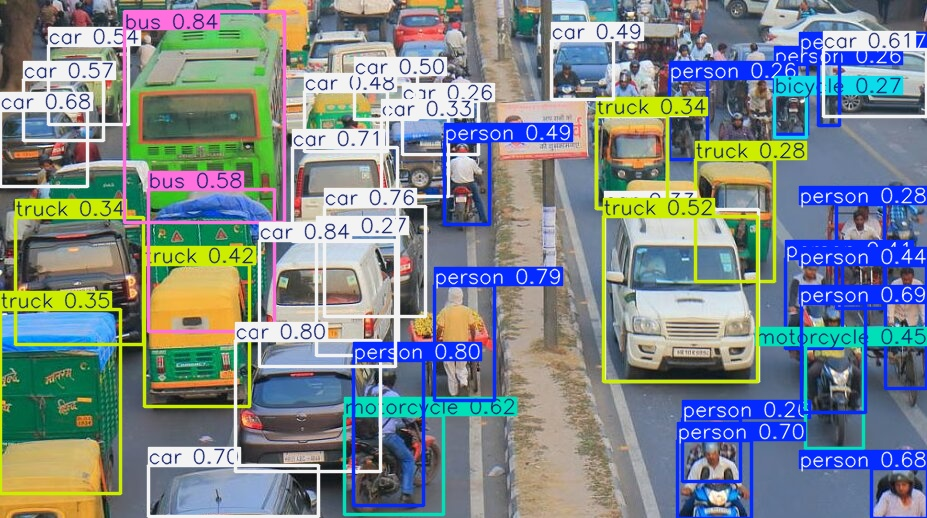

In [ ]:
from PIL import Image

Image.open("output.jpg")

In [ ]:
result = results[0]

names = result.names

detected_objects = []

for cls in result.boxes.cls:
    detected_objects.append(
        names[int(cls)]
    )

print(detected_objects)

['car', 'bus', 'person', 'car', 'person', 'car', 'car', 'car', 'person', 'person', 'person', 'car', 'motorcycle', 'car', 'bus', 'car', 'car', 'truck', 'car', 'car', 'person', 'car', 'motorcycle', 'person', 'truck', 'person', 'truck', 'truck', 'truck', 'car', 'car', 'car', 'person', 'truck', 'car', 'person', 'bicycle', 'car', 'person', 'person', 'person']


In [ ]:
from collections import Counter

object_counts = Counter(
    detected_objects
)

print(object_counts)

Counter({'car': 17, 'person': 13, 'truck': 6, 'bus': 2, 'motorcycle': 2, 'bicycle': 1})


In [ ]:
for box in result.boxes:

    cls_id = int(box.cls)

    confidence = float(box.conf)

    print(
        names[cls_id],
        round(confidence,3)
    )

car 0.84
bus 0.835
person 0.805
car 0.804
person 0.789
car 0.758
car 0.711
car 0.701
person 0.7
person 0.686
person 0.684
car 0.68
motorcycle 0.619
car 0.609
bus 0.575
car 0.569
car 0.545
truck 0.524
car 0.503
car 0.49
person 0.488
car 0.482
motorcycle 0.445
person 0.44
truck 0.416
person 0.415
truck 0.348
truck 0.337
truck 0.335
car 0.33
car 0.329
car 0.297
person 0.277
truck 0.275
car 0.274
person 0.269
bicycle 0.265
car 0.264
person 0.263
person 0.262
person 0.26


In [ ]:
report = []

for box in result.boxes:

    report.append({
        "Object":
        names[int(box.cls)],

        "Confidence":
        float(box.conf)
    })

df = pd.DataFrame(report)

df

,Object,Confidence
0,car,0.839701
1,bus,0.835349
2,person,0.804651
3,car,0.804266
4,person,0.788603
5,car,0.758209
6,car,0.711273
7,car,0.700905
8,person,0.700456
9,person,0.685633


In [ ]:
df.to_csv(
    "detection_report.csv",
    index=False
)

In [ ]:
from google.colab import files

files.download(
    "detection_report.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
uploaded = files.upload()

Saving traffic.mp4 to traffic.mp4


In [25]:
results = model.predict(
    source="traffic.mp4",
    save=True
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/678) /content/traffic.mp4: 384x640 26 cars, 2 buss, 1 truck, 44.9ms
video 1/1 (frame 2/678) /content/traffic.mp4: 384x640 24 cars, 3 buss, 1 truck, 17.3ms
video 1/1 (frame 3/678) /content/traffic.mp4: 384x640 27 cars, 2 buss, 1 truck, 2 traffic lights, 17.7ms
video 1/1 (frame 4/678) /content/traffic.mp4: 384x640 25 cars, 2 buss, 2 trucks, 2 traffic lights, 23.0ms
video 1/1 (frame 5/678) /content/traffic.mp4: 384x640 24 cars, 2 buss, 2 

In [26]:
import os

os.listdir(
    "runs/detect/predict"
)

['traffic.avi']

In [27]:
all_objects = []

for result in results:

    for cls in result.boxes.cls:

        all_objects.append(
            result.names[int(cls)]
        )

counts = Counter(
    all_objects
)

print(counts)

Counter({'car': 16401, 'bus': 1442, 'traffic light': 490, 'truck': 234, 'parking meter': 11, 'train': 11, 'person': 7})


In [28]:
video_report = pd.DataFrame(
    counts.items(),
    columns=[
        "Object",
        "Count"
    ]
)

video_report

,Object,Count
0,bus,1442
1,car,16401
2,truck,234
3,traffic light,490
4,person,7
5,parking meter,11
6,train,11


In [30]:
video_report.to_csv(
    "video_report.csv",
    index=False
)